In [10]:
import sunpy 
import sunpy.map
# from sunpy import map
import matplotlib.pyplot as plt 
import numpy as np 
import astropy
from astropy.visualization import ImageNormalize, AsinhStretch, LogStretch, SqrtStretch, PowerStretch
import astropy.units as u 
import astropy.constants as const 
from astropy.coordinates import SkyCoord
# equivalent to import astropy.coordinates.SkyCoord as SkyCoord
from astropy.time import Time
from astropy.io import fits
from sunpy.data.sample import AIA_171_IMAGE

In [1]:
# this doesnt work, have to import sunpy.map 
import sunpy 
aia_map = sunpy.map.Map("../EIS_DKIST_SolO/src/AIA/20221024/193/lvl15/aia.lev1_euv_12s.2022-10-24T192003Z.193.image.fits")

AttributeError: module 'sunpy' has no attribute 'map'

In [5]:
AIA_171_IMAGE

PosixPath('/home/yjzhu/.local/share/sunpy/AIA20110607_063302_0171_lowres.fits')

In [6]:
# aia_map = sunpy.map.Map("../EIS_DKIST_SolO/src/AIA/20221024/193/lvl15/aia.lev1_euv_12s.2022-10-24T192003Z.193.image.fits")
aia_map = sunpy.map.Map(AIA_171_IMAGE)

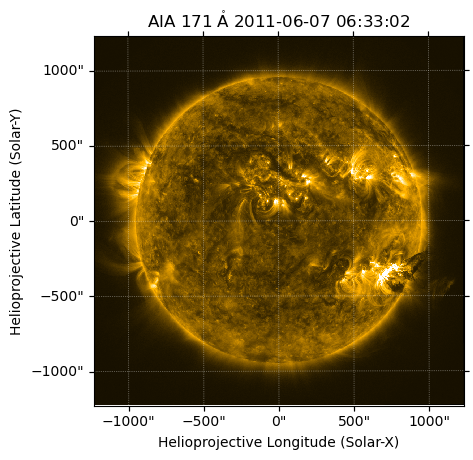

In [9]:
aia_map.plot(
    norm=ImageNormalize(
        vmin=np.nanpercentile(aia_map.data,0.1),
        vmax=np.nanpercentile(aia_map.data,99.9),
        stretch=AsinhStretch()
    )
)

In [11]:
help(AsinhStretch)

Help on class AsinhStretch in module astropy.visualization.stretch:

class AsinhStretch(BaseStretch)
 |  AsinhStretch(a=0.1)
 |
 |  An asinh stretch.
 |
 |  The stretch is given by:
 |
 |  .. math::
 |      y = \frac{{\rm asinh}(x / a)}{{\rm asinh}(1 / a)}.
 |
 |  Parameters
 |  ----------
 |  a : float, optional
 |      The ``a`` parameter used in the above formula. The value of this
 |      parameter is where the asinh curve transitions from linear to
 |      logarithmic behavior, expressed as a fraction of the normalized
 |      image. The stretch becomes more linear for larger ``a`` values
 |      and more logarithmic for smaller ``a`` values. ``a`` must be
 |      greater than 0. Default is 0.1.
 |
 |  Examples
 |  --------
 |  .. plot::
 |      :show-source-link:
 |
 |      import numpy as np
 |      from astropy.visualization import AsinhStretch
 |      from matplotlib import pyplot as plt
 |
 |      fig, ax = plt.subplots(figsize=(5, 5))
 |
 |      x = np.linspace(0, 1, 100)
 |

In [13]:
# save it to fits

aia_map.save("./data/aia_map_saved.fits", overwrite=True)

In [15]:
# create a sequence
aia_map_seq = sunpy.map.Map([AIA_171_IMAGE]*2, sequence=True)

In [16]:
# shape
aia_map_seq.data.shape

(1024, 1024, 2)

In [17]:
# common save does not work 

aia_map_seq.save("./data/aia_map_seq_saved.fits")

ValueError: '{index}' must be appear in the string

In [28]:
# how to do it correctly to save the sequence 

aia_map_seq.save("./data/aia_map_seq_saved_{index}.fits")

In [33]:
# format string in python 

name = "Yingjie"
sentence = "{} writes python"

# first way 
sentence.format(name)

'Yingjie writes python'

In [31]:
"{} writes python".format(name)

'Yingjie writes python'

In [35]:
# second 
f"{name} writes Python"

'Yingjie writes Python'

In [39]:
sentence_2 = "{} writes Python, {} writes IDL"

# first way 
sentence_2.format("Yingjie", "Louise")

'Yingjie writes Python, Louise writes IDL'

In [43]:
# second way 
name_1 = "Yingjie"
name_2 = "Louise"

f"{name_1} writes Python, {name_2} write IDL"

'Yingjie writes Python, Louise write IDL'

In [45]:
number = 125

# first way 
print("the number is {:5d}".format(number))
print("the number is {:05d}".format(number))

the number is   125
the number is 00125


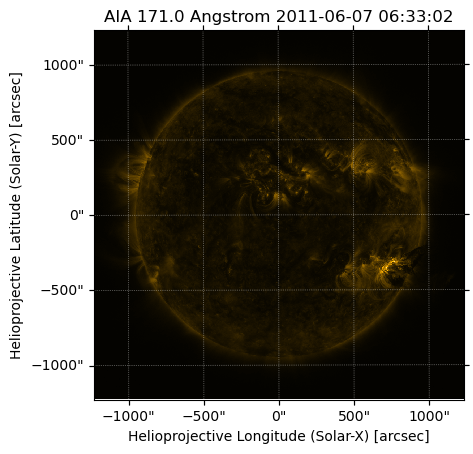

In [19]:
anim = aia_map_seq.plot() # by default the plot in jupyter notebook is static

In [20]:
# save it to mp4 

anim.save("./data/aia_movie.mp4")

In [21]:
from IPython.display import HTML

HTML(anim.to_jshtml())

In [ ]:
# conda install -c conda-forge ipympl
# pip install ipympl

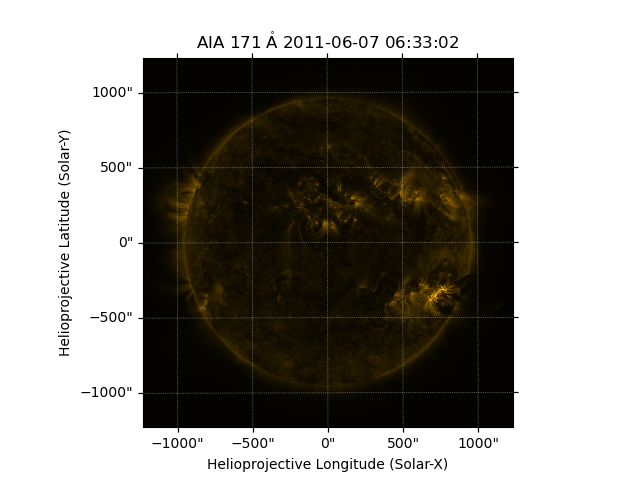

In [27]:
# magic word to make it directly interactive 
plt.close("all")

%matplotlib ipympl
aia_map_seq.plot()